# Enrique Alexander Luna Sánchez A00574602

## 0. Contexto

Se modela la brecha entre exceso real y configurado en Diámetro Exterior, definida como la diferencia entre ambos. Esta es la dimensión donde el sesgo positivo del proceso es sistemático según el EDA. La pregunta es identificar segmentos donde el algoritmo actual deja material sobrante y proponer una reducción conservadora candidata a piloto. La calidad no se modela como variable objetivo porque el 85 por ciento de los defectos no son dimensionales.

## 1. Carga, limpieza y construcción de variables

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.3f}'.format)
RNG = 42

In [ ]:
# Cargar y limpiar columnas con coma como separador de miles
df = pd.read_csv('/content/Grupo201_Santa Catarina Base de Datos 6 meses Rev 1.csv',
                low_memory=False)
df = df.dropna(subset=['Orden']).reset_index(drop=True)

cols_numericas_sucias = ['DE Final','DI Final','Peso de Forja Configurado',
                         'DE Forja Real 1','DE Forja Real 2','DI Forja Real 1',
                         'DI Forja Real 2','Peso Calculado']
for c in cols_numericas_sucias:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',',''), errors='coerce')

print(f"Registros: {len(df)}")

Registros: 7243


In [ ]:
# Promedio de M1 y M2 reduce ruido de medición
df['Exc_Real_DE']     = (df['DE Exceso Real 1'] + df['DE Exceso Real 2']) / 2
df['Brecha_DE']       = df['Exc_Real_DE'] - df['Exceso DE configurado']
df['log_Peso_Config'] = np.log1p(df['Peso de Forja Configurado'])
df['Defecto']         = df['Calidad'].isin(['Rechazo','Reproceso']).astype(int)

print(df[['Exc_Real_DE','Brecha_DE','log_Peso_Config','Defecto']].describe().round(2))

       Exc_Real_DE  Brecha_DE  log_Peso_Config  Defecto
count     7243.000   7243.000         7243.000 7243.000
mean        21.840      2.370            5.130    0.010
std          6.210      4.080            1.040    0.110
min          7.000    -21.000            3.000    0.000
25%         17.000      0.000            4.390    0.000
50%         21.000      2.000            5.010    0.000
75%         26.000      5.000            5.830    0.000
max         52.000     27.000            7.840    1.000


In [ ]:
df_mod = df[df['Roladora'].isin(['R1','R2','R3'])].copy()
df_mod = df_mod[df_mod['Familia geométrica'] != 'Arandela 4'].copy().reset_index(drop=True)

print(f"Registros antes de filtros: {len(df)}")
print(f"Registros tras filtros:     {len(df_mod)}")
print(f"\nFamilias retenidas:\n{df_mod['Familia geométrica'].value_counts()}")

Registros antes de filtros: 7243
Registros tras filtros:     6896

Familias retenidas:
Familia geométrica
Cuadrado 3      3598
Casquillo 1      779
Cuadrado 1       769
Casquillo 4      725
Casquillo 6      496
Casquillo 8      290
Arandela 3       216
Casquillo 10      23
Name: count, dtype: int64


## 2. Evidencia visual, ¿existe brecha sistemática?

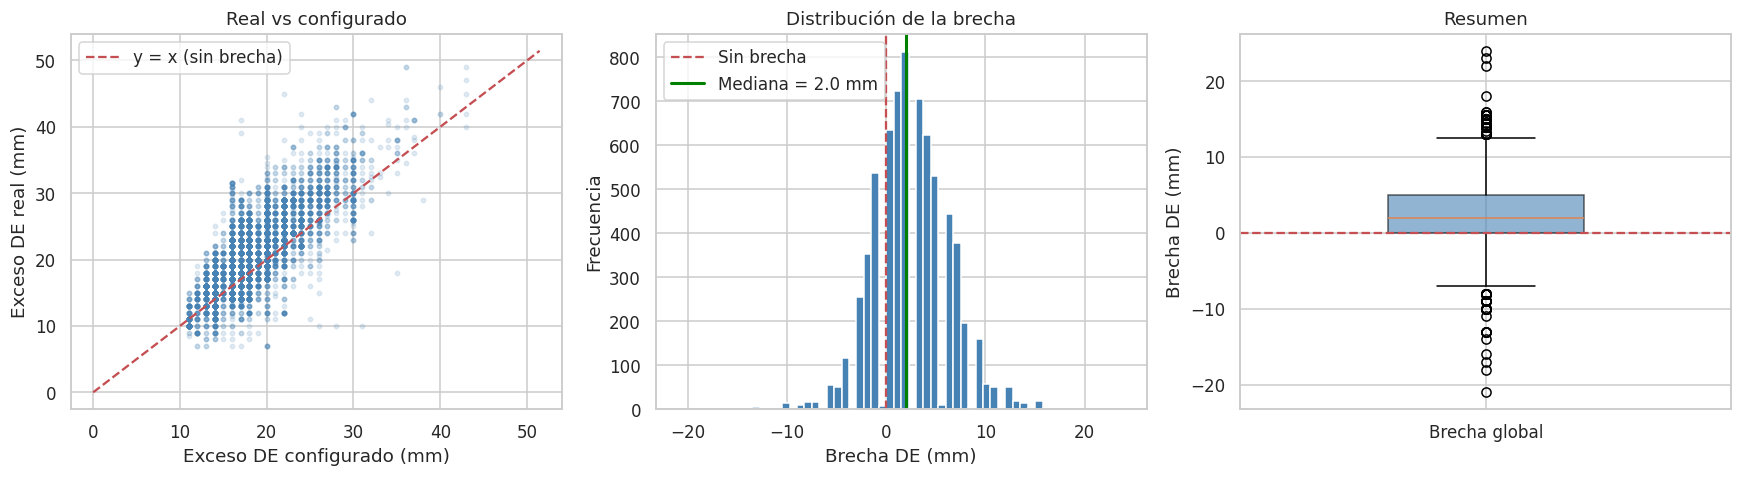

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(df_mod['Exceso DE configurado'], df_mod['Exc_Real_DE'],
                alpha=0.15, s=8, color='steelblue')
lim = [0, df_mod[['Exceso DE configurado','Exc_Real_DE']].max().max()*1.05]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='y = x (sin brecha)')
axes[0].set_xlabel('Exceso DE configurado (mm)')
axes[0].set_ylabel('Exceso DE real (mm)')
axes[0].set_title('Real vs configurado'); axes[0].legend()

axes[1].hist(df_mod['Brecha_DE'], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='r', linestyle='--', lw=1.5, label='Sin brecha')
axes[1].axvline(df_mod['Brecha_DE'].median(), color='green', lw=2,
                label=f"Mediana = {df_mod['Brecha_DE'].median():.1f} mm")
axes[1].set_xlabel('Brecha DE (mm)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de la brecha'); axes[1].legend()

axes[2].boxplot(df_mod['Brecha_DE'], vert=True, widths=0.4, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].axhline(0, color='r', linestyle='--', lw=1.5)
axes[2].set_ylabel('Brecha DE (mm)'); axes[2].set_title('Resumen')
axes[2].set_xticklabels(['Brecha global'])

plt.tight_layout(); plt.show()

In [ ]:
pct_positiva = (df_mod['Brecha_DE'] > 0).mean() * 100
mediana      = df_mod['Brecha_DE'].median()
media        = df_mod['Brecha_DE'].mean()

print(f"Piezas con brecha > 0:  {pct_positiva:.1f}%")
print(f"Brecha mediana:         {mediana:.2f} mm")
print(f"Brecha media:           {media:.2f} mm")

Piezas con brecha > 0:  69.9%
Brecha mediana:         2.00 mm
Brecha media:           2.46 mm


La brecha es positiva en la mayoría de las piezas pero no es uniforme. Algunas salen cerca del configurado, otras varios milímetros por encima, y algunas por debajo. No conviene proponer una reducción global. El siguiente paso identifica en qué segmentos ocurre el sobrante.

## 3. Evidencia visual: ¿la brecha depende de familia y roladora?

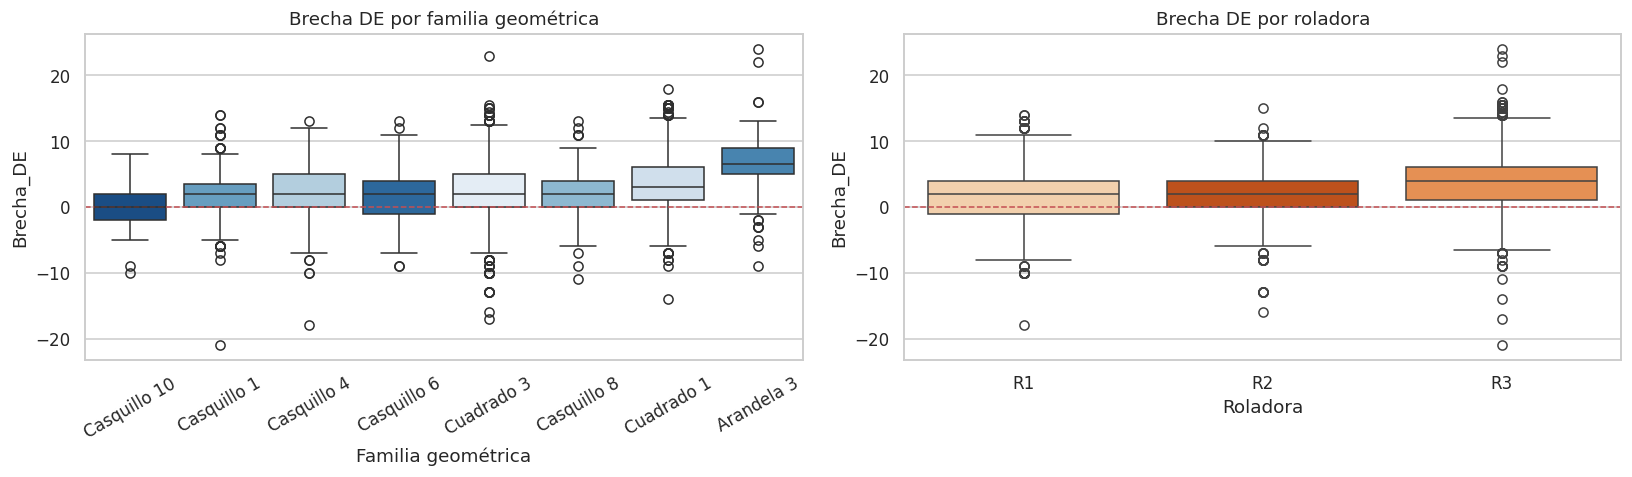

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

orden_fam = df_mod.groupby('Familia geométrica', observed=True)['Brecha_DE'].median().sort_values().index
sns.boxplot(data=df_mod, x='Familia geométrica', y='Brecha_DE',
            hue='Familia geométrica', order=orden_fam, palette='Blues',
            legend=False, ax=axes[0])
axes[0].axhline(0, color='r', linestyle='--', lw=1)
axes[0].set_title('Brecha DE por familia geométrica')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_mod, x='Roladora', y='Brecha_DE',
            hue='Roladora', order=['R1','R2','R3'], palette='Oranges',
            legend=False, ax=axes[1])
axes[1].axhline(0, color='r', linestyle='--', lw=1)
axes[1].set_title('Brecha DE por roladora')

plt.tight_layout(); plt.show()

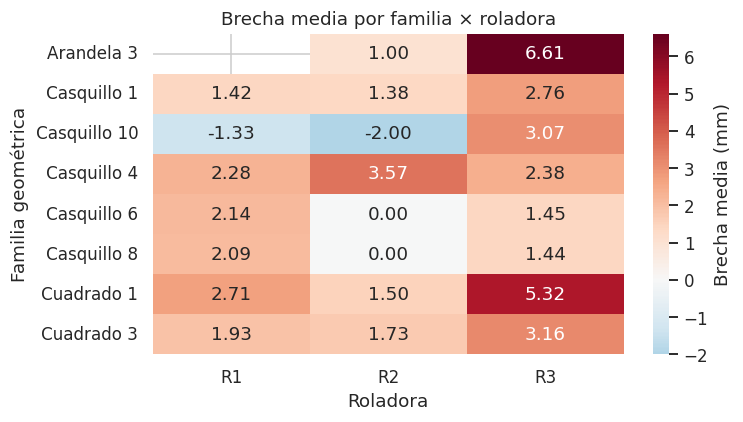

In [ ]:
pivot = df_mod.pivot_table(values='Brecha_DE', index='Familia geométrica',
                           columns='Roladora', aggfunc='mean')

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label':'Brecha media (mm)'})
plt.title('Brecha media por familia × roladora')
plt.tight_layout(); plt.show()

In [ ]:
for var in ['Familia geométrica','Roladora']:
    grupos = [g['Brecha_DE'].values for _, g in df_mod.groupby(var)]
    f, p = stats.f_oneway(*grupos)
    print(f"ANOVA por {var}: F={f:.1f}, p={p:.2e}")

ANOVA por Familia geométrica: F=54.7, p=1.88e-76
ANOVA por Roladora: F=188.7, p=1.67e-80


El heatmap muestra que el efecto de la roladora depende de la familia. Esto justifica probar después una especificación con interacción Familia por Roladora.

## 4. Evidencia visual: ¿la brecha depende del tamaño y del exceso configurado?

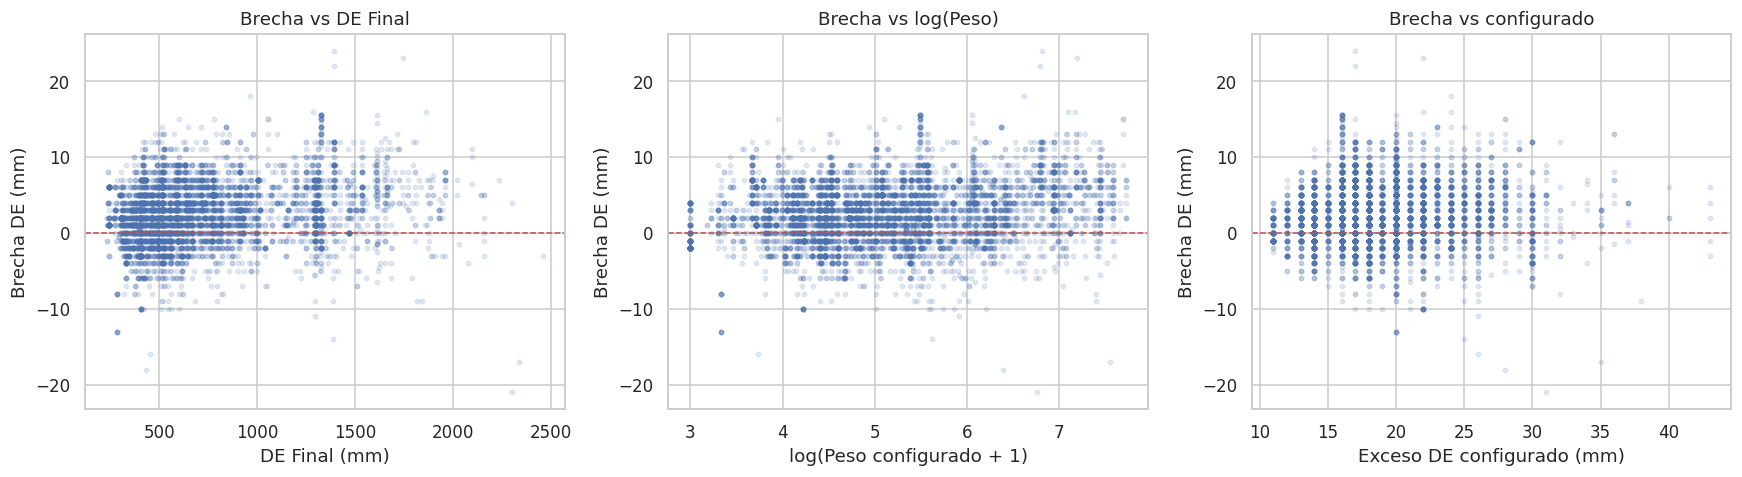

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(df_mod['DE Final'], df_mod['Brecha_DE'], alpha=0.15, s=8)
axes[0].axhline(0, color='r', linestyle='--', lw=1)
axes[0].set_xlabel('DE Final (mm)'); axes[0].set_ylabel('Brecha DE (mm)')
axes[0].set_title('Brecha vs DE Final')

axes[1].scatter(df_mod['log_Peso_Config'], df_mod['Brecha_DE'], alpha=0.15, s=8)
axes[1].axhline(0, color='r', linestyle='--', lw=1)
axes[1].set_xlabel('log(Peso configurado + 1)'); axes[1].set_ylabel('Brecha DE (mm)')
axes[1].set_title('Brecha vs log(Peso)')

axes[2].scatter(df_mod['Exceso DE configurado'], df_mod['Brecha_DE'], alpha=0.15, s=8)
axes[2].axhline(0, color='r', linestyle='--', lw=1)
axes[2].set_xlabel('Exceso DE configurado (mm)'); axes[2].set_ylabel('Brecha DE (mm)')
axes[2].set_title('Brecha vs configurado')

plt.tight_layout(); plt.show()

In [ ]:
corr_tabla = df_mod[['DE Final','log_Peso_Config','Exceso DE configurado','Brecha_DE']].corr()
corr_tabla[['Brecha_DE']].round(3)

,Brecha_DE
DE Final,0.235
log_Peso_Config,0.204
Exceso DE configurado,0.058
Brecha_DE,1.000


El log del peso configurado es proxy de tamaño con menor asimetría que DE Final. Se elige como única variable de tamaño para evitar redundancia, dado que peso, DE, DI y altura están correlacionados entre sí.

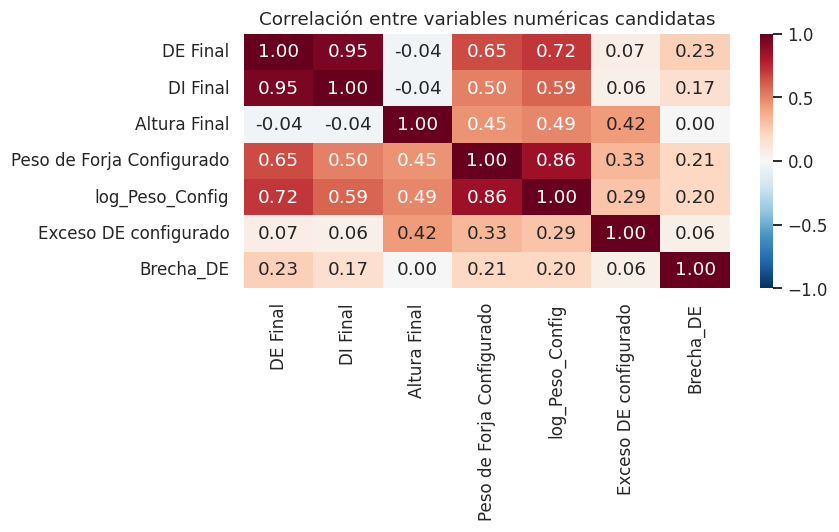

In [ ]:
# Heatmap de correlación entre variables continuas candidatas

cols_corr = ['DE Final', 'DI Final', 'Altura Final',
             'Peso de Forja Configurado', 'log_Peso_Config',
             'Exceso DE configurado', 'Brecha_DE']
corr_matrix = df_mod[cols_corr].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas candidatas')
plt.tight_layout()
plt.show()

## 5. Filtro de seguridad por defectos

La calidad se usa como filtro de seguridad para no recomendar reducción en segmentos riesgosos, no como variable objetivo.

In [ ]:
tasa_fam = df_mod.groupby('Familia geométrica', observed=True)['Defecto'].agg(['size','mean']).round(3)
tasa_fam.columns = ['n','tasa_defecto']

tasa_rol = df_mod.groupby('Roladora', observed=True)['Defecto'].agg(['size','mean']).round(3)
tasa_rol.columns = ['n','tasa_defecto']

print("Por familia:"); print(tasa_fam)
print("\nPor roladora:"); print(tasa_rol)

Por familia:
                       n  tasa_defecto
Familia geométrica                    
Arandela 3           216         0.019
Casquillo 1          779         0.010
Casquillo 10          23         0.000
Casquillo 4          725         0.026
Casquillo 6          496         0.010
Casquillo 8          290         0.024
Cuadrado 1           769         0.020
Cuadrado 3          3598         0.007

Por roladora:
             n  tasa_defecto
Roladora                    
R1        2476         0.015
R2        2255         0.008
R3        2165         0.013


In [ ]:
df_mod.groupby('Calidad', observed=True)['Brecha_DE'].agg(['size','mean','median']).round(2)

,size,mean,median
Calidad,,,
Pieza buena,6813,2.480,2.000
Rechazo,21,3.480,4.000
Reproceso,62,-0.190,0.000


La brecha promedio es similar entre piezas buenas, reproceso y rechazo, lo que refuerza que el exceso no es el driver causal de los defectos. La tasa de defecto se usa solo como umbral del 5 por ciento en la selección de candidatos.

## 6. Selección final de variables

## 6. Selección final de variables

| Variable | Decisión | Justificación |
|---|---|---|
| Familia geométrica | Sí | ANOVA F=54.7 con p cercano a 10 a la menos 76, el EDA mostró diferencias claras |
| Roladora | Sí | ANOVA F=188.7 con p cercano a 10 a la menos 80 |
| log_Peso_Config | Sí | Proxy de tamaño con menor asimetría que peso bruto |
| Exceso DE configurado | Sí | Permite evaluar si el algoritmo se autocorrige |
| R3 por log_Peso | Sí | Interacción que captura el efecto distinto del tamaño en R3, dado que R3 procesa piezas mucho más grandes |
| DE Final, DI Final, Altura Final | No | Redundantes con peso, correlaciones mayores a 0.8 entre ellas |
| Relación E/A Finales | No | Casi define la familia geométrica |
| Ovalamiento, Pandeamiento, Conicidad | No | Data leakage, son medidas posteriores a la forja |
| DE/DI/Altura Exceso Real 1, 2 | No | Componen Y directamente |
| Calidad, Motivo | No | Posteriores al proceso, se usan solo como filtro de seguridad |
| Orden, N Cliente | No | Identificadores, alta cardinalidad sin justificación conceptual |
| Rango peso, Rango DE | No | Discretizaciones del peso continuo, usamos el continuo |

In [ ]:
# Matriz de diseño con log_Peso centrado
# Centrar evita la multicolinealidad estructural entre R3 y la interacción R3 por log_Peso
fam_cats = ['Cuadrado 3'] + [f for f in df_mod['Familia geométrica'].unique() if f != 'Cuadrado 3']
rol_cats = ['R1','R2','R3']

df_mod['Familia geométrica'] = pd.Categorical(df_mod['Familia geométrica'], categories=fam_cats)
df_mod['Roladora']           = pd.Categorical(df_mod['Roladora'], categories=rol_cats)

# Centrar log_Peso para que el coeficiente de R3 represente el efecto en el peso medio
df_mod['log_Peso_c'] = df_mod['log_Peso_Config'] - df_mod['log_Peso_Config'].mean()

X_cat = pd.get_dummies(df_mod[['Familia geométrica','Roladora']], drop_first=True, dtype=float)
X_num = df_mod[['log_Peso_c','Exceso DE configurado']].astype(float)

R3_dummy = (df_mod['Roladora'] == 'R3').astype(float)
X_int = pd.DataFrame({'R3_x_logPeso_c': R3_dummy * df_mod['log_Peso_c']}, index=df_mod.index)

X = pd.concat([X_cat, X_num, X_int], axis=1)
y = df_mod['Brecha_DE'].astype(float)

print(f"Matriz de diseño: {X.shape}")
print(f"Predictores: {list(X.columns)}")

Matriz de diseño: (6896, 12)
Predictores: ['Familia geométrica_Cuadrado 1', 'Familia geométrica_Casquillo 4', 'Familia geométrica_Casquillo 8', 'Familia geométrica_Casquillo 1', 'Familia geométrica_Arandela 3', 'Familia geométrica_Casquillo 6', 'Familia geométrica_Casquillo 10', 'Roladora_R2', 'Roladora_R3', 'log_Peso_c', 'Exceso DE configurado', 'R3_x_logPeso_c']


## Continuacion

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)
vif = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).query('variable != "const"').sort_values('VIF', ascending=False)
vif.round(2)

,variable,VIF
12,R3_x_logPeso_c,5.460
9,Roladora_R3,4.370
10,log_Peso_c,3.880
8,Roladora_R2,1.620
11,Exceso DE configurado,1.490
2,Familia geométrica_Casquillo 4,1.290
5,Familia geométrica_Arandela 3,1.230
3,Familia geométrica_Casquillo 8,1.190
6,Familia geométrica_Casquillo 6,1.190
1,Familia geométrica_Cuadrado 1,1.170


Tras centrar log_Peso, los VIF de Roladora R3 y de la interacción R3 por log_Peso bajan a 4.4 y 5.5 respectivamente, ambos en rango aceptable. Sin centrar habrían quedado por encima de 90 por la correlación estructural entre la dummy R3 y el producto R3 por log_Peso. El centrado no afecta el ajuste del modelo pero sí estabiliza los coeficientes y permite interpretarlos en el peso medio del dataset. Los demás predictores tienen VIF por debajo de 4.

## 7. Modelo 1, OLS-A

Modelo base interpretable. Incluye la interacción R3 por log_Peso desde el inicio porque el EDA reveló confounding entre roladora y tamaño. Se usan errores estándar robustos HC3 para corregir la heterocedasticidad esperada entre familias.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG,
    stratify=df_mod['Familia geométrica']
)

ols_a = sm.OLS(y_train, sm.add_constant(X_train)).fit(cov_type='HC3')
print(ols_a.summary())

                            OLS Regression Results                            
Dep. Variable:              Brecha_DE   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     41.49
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.73e-94
Time:                        07:10:43   Log-Likelihood:                -14921.
No. Observations:                5516   AIC:                         2.987e+04
Df Residuals:                    5503   BIC:                         2.995e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [ ]:
y_hat_tr = ols_a.predict(sm.add_constant(X_train))
y_hat_te = ols_a.predict(sm.add_constant(X_test))

print(f"R² train:   {r2_score(y_train, y_hat_tr):.3f}")
print(f"R² test:    {r2_score(y_test,  y_hat_te):.3f}")
print(f"RMSE test:  {mean_squared_error(y_test, y_hat_te) ** 0.5:.2f} mm")
print(f"MAE test:   {mean_absolute_error(y_test, y_hat_te):.2f} mm")

R² train:   0.094
R² test:    0.057
RMSE test:  3.86 mm
MAE test:   2.98 mm


In [ ]:
coef_a = pd.DataFrame({
    'Coef': ols_a.params,
    'Std Err': ols_a.bse,
    'p-valor': ols_a.pvalues,
    'IC 2.5%': ols_a.conf_int()[0],
    'IC 97.5%': ols_a.conf_int()[1],
}).round(3)
coef_a['Sig'] = coef_a['p-valor'].apply(
    lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
)
coef_a

,Coef,Std Err,p-valor,IC 2.5%,IC 97.5%,Sig
const,1.601,0.301,0.000,1.010,2.191,***
Familia geométrica_Cuadrado 1,1.028,0.176,0.000,0.682,1.374,***
Familia geométrica_Casquillo 4,0.661,0.189,0.000,0.290,1.032,***
Familia geométrica_Casquillo 8,-0.280,0.273,0.306,-0.815,0.256,
Familia geométrica_Casquillo 1,-0.504,0.141,0.000,-0.780,-0.228,***
Familia geométrica_Arandela 3,2.907,0.343,0.000,2.234,3.580,***
Familia geométrica_Casquillo 6,-0.223,0.205,0.276,-0.625,0.178,
Familia geométrica_Casquillo 10,-2.696,1.084,0.013,-4.821,-0.571,*
Roladora_R2,-0.228,0.126,0.071,-0.475,0.020,
Roladora_R3,0.783,0.239,0.001,0.315,1.251,**


In [ ]:
# Métricas adicionales del OLS-A: F global, R² ajustado, validación cruzada
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# F estadístico global del OLS-A (test conjunto: todos los coeficientes = 0)
f_stat = ols_a.fvalue
f_pval = ols_a.f_pvalue
print(f"F estadístico global: {f_stat:.2f}")
print(f"p-valor F global:     {f_pval:.2e}")
print(f"R² ajustado:          {ols_a.rsquared_adj:.3f}")

# Validación cruzada 5-fold con sklearn (equivalente a OLS-A)
kf = KFold(n_splits=5, shuffle=True, random_state=RNG)
lr = LinearRegression()
cv_r2   = cross_val_score(lr, X, y, cv=kf, scoring='r2')
cv_rmse = -cross_val_score(lr, X, y, cv=kf, scoring='neg_root_mean_squared_error')

print(f"\nValidación cruzada 5-fold:")
print(f"  R² CV:   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"  RMSE CV: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f} mm")

F estadístico global: 41.49
p-valor F global:     1.73e-94
R² ajustado:          0.092

Validación cruzada 5-fold:
  R² CV:   0.083 ± 0.016
  RMSE CV: 3.67 ± 0.07 mm


### 7.1 Diagnósticos de supuestos

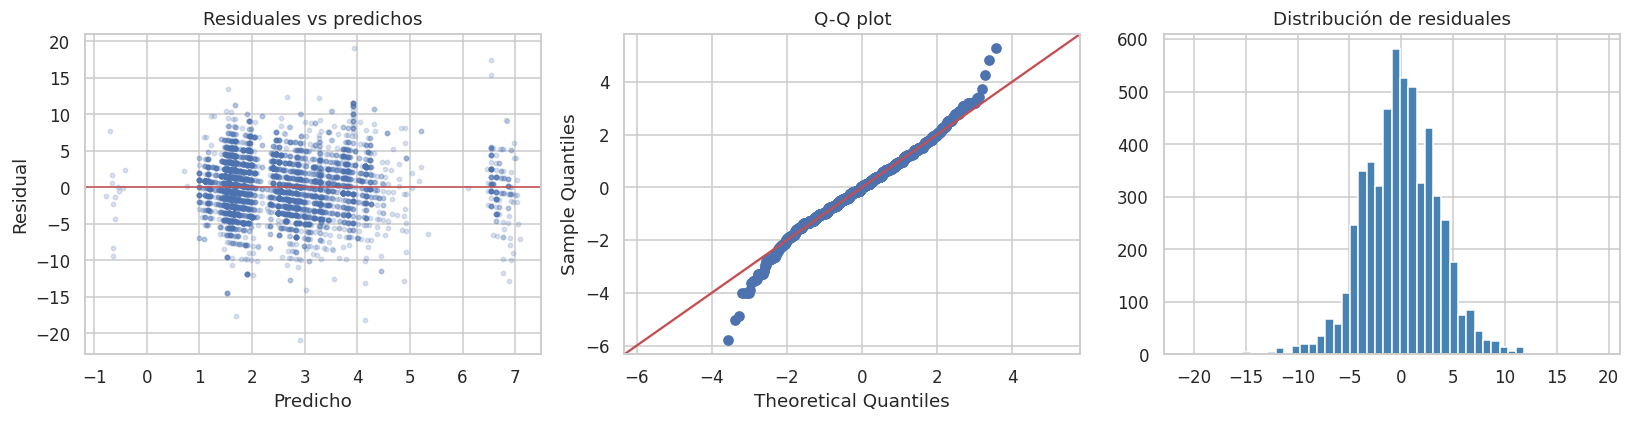

In [ ]:
resid = y_train - y_hat_tr

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_hat_tr, resid, alpha=0.2, s=8)
axes[0].axhline(0, color='r', lw=1)
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuales vs predichos')

sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot')

axes[2].hist(resid, bins=50, edgecolor='white', color='steelblue')
axes[2].set_title('Distribución de residuales')

plt.tight_layout(); plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_p, _, _ = het_breuschpagan(resid, sm.add_constant(X_train))
print(f"Breusch-Pagan (heterocedasticidad): LM={bp_stat:.1f}, p={bp_p:.2e}")
print("→ Se rechaza homocedasticidad: HC3 corrige los IC del OLS.")

Breusch-Pagan (heterocedasticidad): LM=159.0, p=8.56e-28
→ Se rechaza homocedasticidad: HC3 corrige los IC del OLS.


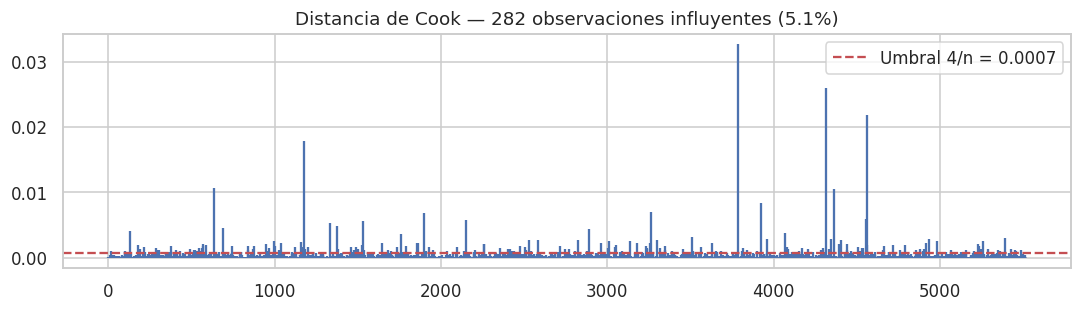

In [ ]:
cooks = ols_a.get_influence().cooks_distance[0]
umbral = 4 / len(y_train)
n_inf = (cooks > umbral).sum()

plt.figure(figsize=(10, 3))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=' ', basefmt=' ')
plt.axhline(umbral, color='r', linestyle='--', label=f'Umbral 4/n = {umbral:.4f}')
plt.title(f"Distancia de Cook — {n_inf} observaciones influyentes ({n_inf/len(y_train)*100:.1f}%)")
plt.legend(); plt.tight_layout(); plt.show()

El R cuadrado del modelo es modesto. El modelo captura las diferencias promedio entre familias y roladoras, no el ruido pieza a pieza, que tiene fuentes no observadas como lote de acero, operador o calibración del día. Para identificar segmentos con brecha sistemática, los coeficientes y sus intervalos de confianza son más informativos que el R cuadrado.

## 8. Comparación de especificaciones OLS

Se prueban seis variantes para verificar si los hallazgos del modelo base se mantienen al cambiar la especificación. M1 usa solo familia. M2 agrega roladora. M3 agrega log del peso. M4 es el OLS-A completo, que incluye la interacción R3 por log_Peso. M5 es OLS-B con interacciones Familia por Roladora más R3 por log_Peso. M6 es OLS-A excluyendo los percentiles 1 y 99 de la brecha como prueba de robustez ante outliers.

In [ ]:
# Listas de columnas categóricas y numéricas en X
fam_cols = [c for c in X.columns if c.startswith('Familia')]
rol_cols = [c for c in X.columns if c.startswith('Roladora')]

specs = {
    'M1 Solo familia':        fam_cols,
    'M2 Fam+Roladora':        fam_cols + rol_cols,
    'M3 +log_Peso':           fam_cols + rol_cols + ['log_Peso_c'],
    'M4 OLS-A completo':      list(X.columns),
}

In [ ]:
fitted = {}
for nombre, vars_ in specs.items():
    fitted[nombre] = sm.OLS(y_train, sm.add_constant(X_train[vars_])).fit(cov_type='HC3')

In [ ]:
# M5: OLS-B con interacciones Familia x Roladora y R3 x log_Peso, log_Peso centrado
import statsmodels.formula.api as smf

df_train = df_mod.iloc[X_train.index].copy()
df_train['Brecha_DE'] = y_train.values
df_train['R3_x_logPeso_c'] = ((df_train['Roladora']=='R3').astype(float) * df_train['log_Peso_c']).values

formula_b = ('Brecha_DE ~ C(Q("Familia geométrica")) * C(Roladora) '
             '+ log_Peso_c + Q("Exceso DE configurado") + R3_x_logPeso_c')
ols_b = smf.ols(formula_b, data=df_train).fit(cov_type='HC3')
fitted['M5 +interacciones'] = ols_b

In [ ]:
p1, p99 = y_train.quantile([0.01, 0.99])
mask    = (y_train >= p1) & (y_train <= p99)

ols_no_out = sm.OLS(y_train[mask], sm.add_constant(X_train[mask])).fit(cov_type='HC3')
fitted['M6 Sin outliers'] = ols_no_out

print(f"Outliers excluidos en M6: {(~mask).sum()} de {len(y_train)} ({(~mask).mean()*100:.1f}%)")

Outliers excluidos en M6: 102 de 5516 (1.8%)


In [ ]:
# Tabla comparativa de métricas para todas las especificaciones
df_te_b = df_mod.iloc[X_test.index].copy()
df_te_b['R3_x_logPeso_c'] = ((df_te_b['Roladora']=='R3').astype(float) * df_te_b['log_Peso_c']).values

resultados = []
for nombre, mod in fitted.items():
    if nombre == 'M5 +interacciones':
        pred_te = mod.predict(df_te_b)
    elif nombre == 'M6 Sin outliers':
        pred_te = mod.predict(sm.add_constant(X_test))
    else:
        pred_te = mod.predict(sm.add_constant(X_test[specs[nombre]]))

    resultados.append({
        'Especificación': nombre, 'n': int(mod.nobs), 'k': int(mod.df_model),
        'R²': mod.rsquared, 'R²_adj': mod.rsquared_adj,
        'AIC': mod.aic, 'BIC': mod.bic,
        'RMSE_test': mean_squared_error(y_test, pred_te) ** 0.5,
    })

pd.DataFrame(resultados).round(3)

,Especificación,n,k,R²,R²_adj,AIC,BIC,RMSE_test
0,M1 Solo familia,5516,7,0.054,0.053,30094.031,30146.954,3.887
1,M2 Fam+Roladora,5516,9,0.090,0.089,29885.554,29951.709,3.860
2,M3 +log_Peso,5516,10,0.092,0.090,29874.906,29947.676,3.863
3,M4 OLS-A completo,5516,12,0.094,0.092,29868.267,29954.268,3.865
4,M5 +interacciones,5516,25,0.118,0.114,29743.472,29915.473,3.839
5,M6 Sin outliers,5414,12,0.088,0.086,28320.363,28406.120,3.869


In [ ]:
clave = fam_cols + rol_cols
estabilidad = pd.DataFrame({
    nombre: fitted[nombre].params.reindex(clave)
    for nombre in ['M1 Solo familia','M2 Fam+Roladora','M3 +log_Peso','M4 OLS-A completo']
}).round(2)
estabilidad

,M1 Solo familia,M2 Fam+Roladora,M3 +log_Peso,M4 OLS-A completo
Familia geométrica_Cuadrado 1,1.100,0.890,0.940,1.030
Familia geométrica_Casquillo 4,0.360,0.750,0.710,0.660
Familia geométrica_Casquillo 8,-0.280,-0.120,-0.300,-0.280
Familia geométrica_Casquillo 1,-0.540,-0.410,-0.470,-0.500
Familia geométrica_Arandela 3,4.370,3.310,3.100,2.910
Familia geométrica_Casquillo 6,-0.450,-0.140,-0.210,-0.220
Familia geométrica_Casquillo 10,-2.440,-2.430,-2.570,-2.700
Roladora_R2,NaN,-0.260,-0.250,-0.230
Roladora_R3,NaN,1.510,1.040,0.780


## 9. K-best

In [ ]:
from sklearn.feature_selection import f_regression, SelectKBest

selector = SelectKBest(score_func=f_regression, k='all').fit(X_train, y_train)

kbest = pd.DataFrame({
    'variable': X_train.columns,
    'F': selector.scores_,
    'p-valor': selector.pvalues_,
}).sort_values('F', ascending=False).round(3)
kbest

,variable,F,p-valor
11,R3_x_logPeso_c,343.713,0.000
8,Roladora_R3,336.692,0.000
9,log_Peso_c,284.918,0.000
4,Familia geométrica_Arandela 3,225.509,0.000
7,Roladora_R2,100.005,0.000
0,Familia geométrica_Cuadrado 1,40.311,0.000
10,Exceso DE configurado,25.800,0.000
3,Familia geométrica_Casquillo 1,25.797,0.000
5,Familia geométrica_Casquillo 6,11.998,0.001
6,Familia geométrica_Casquillo 10,8.630,0.003


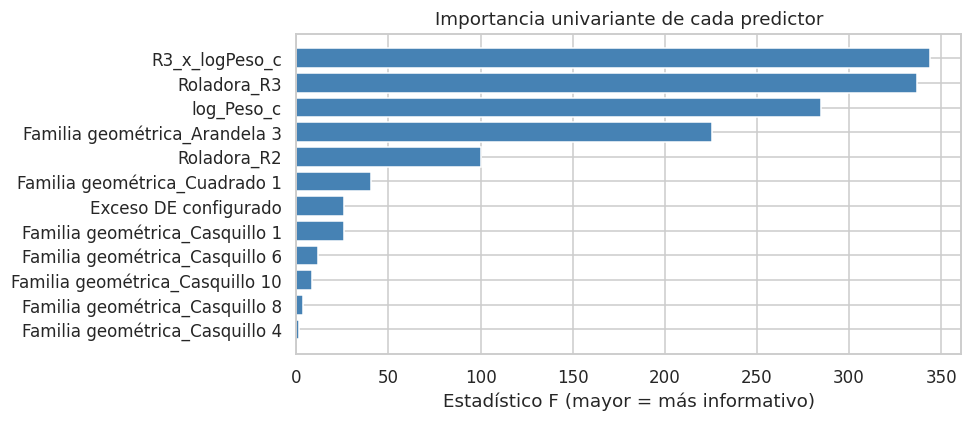

In [ ]:
plt.figure(figsize=(9, 4))
plt.barh(kbest['variable'][::-1], kbest['F'][::-1], color='steelblue')
plt.xlabel('Estadístico F (mayor = más informativo)')
plt.title('Importancia univariante de cada predictor')
plt.tight_layout(); plt.show()

K-best ordena los predictores por su capacidad explicativa univariante. Confirma que las variables incluidas en el modelo son las que cargan la mayor parte de la señal, pero no se usa para selección final porque ignora correlaciones entre predictores.

## 10. Modelo 2, KNN Regressor

KNN no impone forma funcional. Para cada pieza nueva busca las K piezas históricas más parecidas y promedia sus brechas. Se prueban tres versiones para evaluar el sesgo hacia la clase mayoritaria, dado que Cuadrado 3 representa el 52 por ciento del dataset. El tuning de hiperparámetros usa random search de 30 iteraciones seguido de grid exhaustivo en una vecindad del óptimo.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import loguniform, randint

class IntLogUniform:
    def __init__(self, low, high):
        self.dist = loguniform(low, high)
    def rvs(self, *args, **kwargs):
        return int(self.dist.rvs(*args, **kwargs))

def tune_knn_dos_etapas(X_tr, y_tr, weights_fijo, n_iter_random=30, seed=RNG):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(weights=weights_fijo))
    ])

    # Etapa 1: random search amplio
    random_search = RandomizedSearchCV(
        pipe,
        param_distributions={
            'knn__n_neighbors': IntLogUniform(3, 200),
            'knn__p': [1, 2],
        },
        n_iter=n_iter_random, cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=seed, n_jobs=-1
    )
    random_search.fit(X_tr, y_tr)
    k_random = int(random_search.best_params_['knn__n_neighbors'])
    p_random = random_search.best_params_['knn__p']

    # Etapa 2: grid exhaustivo local (±5 vecinos del óptimo random)
    k_grid = list(range(max(3, k_random - 5), k_random + 6))
    grid_search = GridSearchCV(
        pipe,
        param_grid={'knn__n_neighbors': k_grid, 'knn__p': [p_random]},
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    grid_search.fit(X_tr, y_tr)

    return {
        'modelo': grid_search.best_estimator_,
        'k_random': k_random, 'p_random': p_random,
        'rmse_random': -random_search.best_score_,
        'k_final': int(grid_search.best_params_['knn__n_neighbors']),
        'rmse_final': -grid_search.best_score_,
    }

### 10.1 KNN-A — Versión uniforme

In [ ]:
resultado_a = tune_knn_dos_etapas(X_train, y_train, weights_fijo='uniform')
knn_a = resultado_a['modelo']

print(f"Etapa 1 (random): K={resultado_a['k_random']}, p={resultado_a['p_random']}, RMSE={resultado_a['rmse_random']:.3f}")
print(f"Etapa 2 (grid):   K={resultado_a['k_final']}, RMSE={resultado_a['rmse_final']:.3f}")

Etapa 1 (random): K=7, p=2, RMSE=3.178
Etapa 2 (grid):   K=8, RMSE=3.174


### 10.2 KNN-B — Ponderado por distancia

In [ ]:
resultado_b = tune_knn_dos_etapas(X_train, y_train, weights_fijo='distance')
knn_b = resultado_b['modelo']

print(f"Etapa 1 (random): K={resultado_b['k_random']}, p={resultado_b['p_random']}, RMSE={resultado_b['rmse_random']:.3f}")
print(f"Etapa 2 (grid):   K={resultado_b['k_final']}, RMSE={resultado_b['rmse_final']:.3f}")

Etapa 1 (random): K=179, p=1, RMSE=2.969
Etapa 2 (grid):   K=183, RMSE=2.969


### 10.3 KNN-C, balanceado por submuestreo de Cuadrado 3

Submuestreamos Cuadrado 3 a 800 piezas, similar al resto de familias grandes, para evaluar si el balanceo ayuda a generalizar a familias minoritarias.

In [ ]:
n_target = 800
df_train_full = df_mod.iloc[X_train.index].copy()
df_train_full['Brecha_DE'] = y_train.values

cuadrado3_mask = df_train_full['Familia geométrica'] == 'Cuadrado 3'
otras = df_train_full[~cuadrado3_mask]
cuadrado3_sub = df_train_full[cuadrado3_mask].sample(n=n_target, random_state=RNG)

df_balanced = pd.concat([cuadrado3_sub, otras]).sort_index()
print(f"Tamaño antes:   {len(df_train_full)}")
print(f"Tamaño después: {len(df_balanced)}")

Tamaño antes:   5516
Tamaño después: 3438


In [ ]:
X_train_bal = X_train.loc[df_balanced.index]
y_train_bal = y_train.loc[df_balanced.index]

resultado_c = tune_knn_dos_etapas(X_train_bal, y_train_bal, weights_fijo='distance')
knn_c = resultado_c['modelo']

print(f"Etapa 1 (random): K={resultado_c['k_random']}, p={resultado_c['p_random']}, RMSE={resultado_c['rmse_random']:.3f}")
print(f"Etapa 2 (grid):   K={resultado_c['k_final']}, RMSE={resultado_c['rmse_final']:.3f}")

Etapa 1 (random): K=161, p=2, RMSE=3.810
Etapa 2 (grid):   K=166, RMSE=3.803


### 10.4 Hiperparámetros finales

In [ ]:
tuning = pd.DataFrame({
    'KNN-A naive':       resultado_a,
    'KNN-B distancia':   resultado_b,
    'KNN-C balanceado':  resultado_c,
}).T[['k_random','p_random','rmse_random','k_final','rmse_final']]
tuning.round(3)

,k_random,p_random,rmse_random,k_final,rmse_final
KNN-A naive,7,2,3.178,8,3.174
KNN-B distancia,179,1,2.969,183,2.969
KNN-C balanceado,161,2,3.810,166,3.803


### 10.5 Comparación de las tres versiones de KNN

In [ ]:
# Métricas test de los tres KNN sobre el mismo X_test, y_test
def evaluar_knn(modelo, X_te, y_te):
    pred = modelo.predict(X_te)
    return {
        'R²_test':   r2_score(y_te, pred),
        'RMSE_test': mean_squared_error(y_te, pred) ** 0.5,
        'MAE_test':  mean_absolute_error(y_te, pred),
    }

knn_metrics = pd.DataFrame({
    'KNN-A naive':       evaluar_knn(knn_a, X_test, y_test),
    'KNN-B distancia':   evaluar_knn(knn_b, X_test, y_test),
    'KNN-C balanceado':  evaluar_knn(knn_c, X_test, y_test),
}).T.round(3)
knn_metrics

,R²_test,RMSE_test,MAE_test
KNN-A naive,0.318,3.285,2.389
KNN-B distancia,0.402,3.076,2.186
KNN-C balanceado,0.326,3.266,2.304


In [ ]:
# Comparación de errores POR FAMILIA — aquí se ve si hay sesgo del KNN naive
df_test = df_mod.iloc[X_test.index].copy()
df_test['y_true'] = y_test.values
df_test['pred_a'] = knn_a.predict(X_test)
df_test['pred_b'] = knn_b.predict(X_test)
df_test['pred_c'] = knn_c.predict(X_test)

errores_fam = df_test.groupby('Familia geométrica', observed=True).apply(
    lambda g: pd.Series({
        'n_test': len(g),
        'RMSE_A': mean_squared_error(g['y_true'], g['pred_a']) ** 0.5,
        'RMSE_B': mean_squared_error(g['y_true'], g['pred_b']) ** 0.5,
        'RMSE_C': mean_squared_error(g['y_true'], g['pred_c']) ** 0.5,
    }), include_groups=False
).round(2)
errores_fam

,n_test,RMSE_A,RMSE_B,RMSE_C
Familia geométrica,,,,
Cuadrado 3,720.000,3.270,2.950,3.320
Cuadrado 1,154.000,3.650,3.110,3.090
Casquillo 4,145.000,2.550,2.490,2.490
Casquillo 8,58.000,3.250,2.900,2.900
Casquillo 1,156.000,3.380,3.610,3.610
Arandela 3,43.000,3.800,4.140,4.140
Casquillo 6,99.000,3.460,3.370,3.370
Casquillo 10,5.000,2.000,2.090,2.040


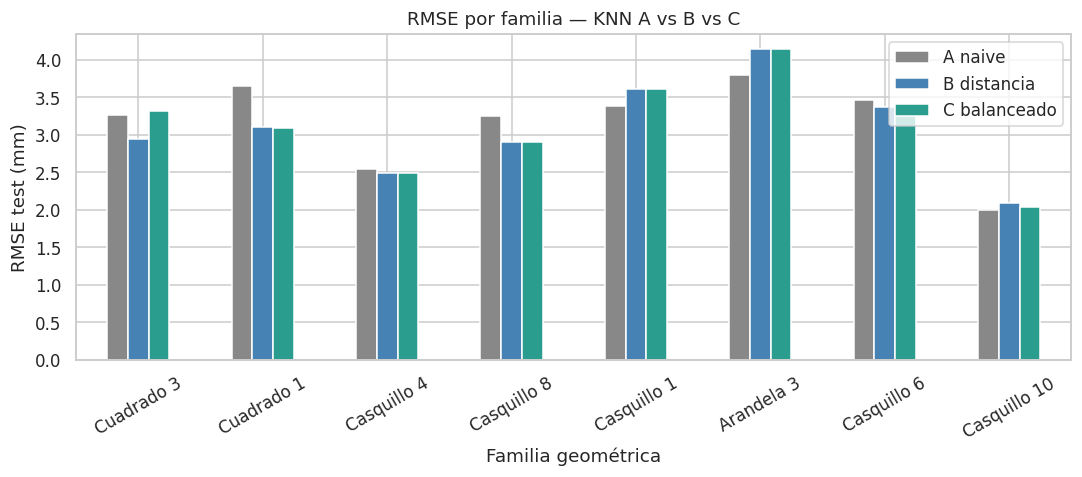

In [ ]:
# Visualización: RMSE por familia para los tres modelos
fig, ax = plt.subplots(figsize=(10, 4.5))
errores_fam[['RMSE_A','RMSE_B','RMSE_C']].plot(kind='bar', ax=ax,
    color=['#888','steelblue','#2a9d8f'])
ax.set_ylabel('RMSE test (mm)')
ax.set_title('RMSE por familia — KNN A vs B vs C')
ax.legend(['A naive','B distancia','C balanceado'])
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

Si KNN-C reduce el RMSE en familias minoritarias como Arandela 3 y Casquillo 10 sin degradar mucho el de Cuadrado 3, confirma que el balanceo era útil. Si KNN-B y KNN-C son equivalentes, el ponderado por distancia ya hacía el trabajo.

## 11. Comparación final OLS vs KNN

¿El modelo no paramétrico (KNN) captura patrones que el OLS pierde, o ambos llegan a las mismas conclusiones?

In [ ]:
# Tabla comparativa final OLS vs KNN
pred_ols_a = ols_a.predict(sm.add_constant(X_test))

df_te_b = df_mod.iloc[X_test.index].copy()
df_te_b['R3_x_logPeso_c'] = ((df_te_b['Roladora']=='R3').astype(float) * df_te_b['log_Peso_c']).values
pred_ols_b = ols_b.predict(df_te_b)

resumen = pd.DataFrame({
    'OLS-A honesto':       {'R²': r2_score(y_test, pred_ols_a),
                            'RMSE': mean_squared_error(y_test, pred_ols_a)**0.5,
                            'MAE': mean_absolute_error(y_test, pred_ols_a),
                            'Interpretabilidad': 'Alta (coef. + IC)'},
    'OLS-B interacciones': {'R²': r2_score(y_test, pred_ols_b),
                            'RMSE': mean_squared_error(y_test, pred_ols_b)**0.5,
                            'MAE': mean_absolute_error(y_test, pred_ols_b),
                            'Interpretabilidad': 'Media (coef. condicionales)'},
    'KNN-A naive':         {'R²': knn_metrics.loc['KNN-A naive','R²_test'],
                            'RMSE': knn_metrics.loc['KNN-A naive','RMSE_test'],
                            'MAE': knn_metrics.loc['KNN-A naive','MAE_test'],
                            'Interpretabilidad': 'Baja (similitud)'},
    'KNN-B distancia':     {'R²': knn_metrics.loc['KNN-B distancia','R²_test'],
                            'RMSE': knn_metrics.loc['KNN-B distancia','RMSE_test'],
                            'MAE': knn_metrics.loc['KNN-B distancia','MAE_test'],
                            'Interpretabilidad': 'Baja (similitud)'},
    'KNN-C balanceado':    {'R²': knn_metrics.loc['KNN-C balanceado','R²_test'],
                            'RMSE': knn_metrics.loc['KNN-C balanceado','RMSE_test'],
                            'MAE': knn_metrics.loc['KNN-C balanceado','MAE_test'],
                            'Interpretabilidad': 'Baja (similitud)'},
}).T
resumen[['R²','RMSE','MAE']] = resumen[['R²','RMSE','MAE']].astype(float).round(3)
resumen

,R²,RMSE,MAE,Interpretabilidad
OLS-A honesto,0.057,3.865,2.985,Alta (coef. + IC)
OLS-B interacciones,0.069,3.839,2.941,Media (coef. condicionales)
KNN-A naive,0.318,3.285,2.389,Baja (similitud)
KNN-B distancia,0.402,3.076,2.186,Baja (similitud)
KNN-C balanceado,0.326,3.266,2.304,Baja (similitud)


In [ ]:
# Predicción comparada por familia
df_test = df_mod.iloc[X_test.index].copy()
df_test['y_true'] = y_test.values
df_test['pred_a'] = knn_a.predict(X_test)
df_test['pred_b'] = knn_b.predict(X_test)
df_test['pred_c'] = knn_c.predict(X_test)
df_test['pred_ols_a'] = ols_a.predict(sm.add_constant(X_test))

preds_familia = df_test.groupby('Familia geométrica', observed=True).agg(
    Brecha_real=('y_true','mean'),
    Pred_OLS_A=('pred_ols_a','mean'),
    Pred_KNN_A=('pred_a','mean'),
    Pred_KNN_B=('pred_b','mean'),
    Pred_KNN_C=('pred_c','mean'),
).round(2)
preds_familia

,Brecha_real,Pred_OLS_A,Pred_KNN_A,Pred_KNN_B,Pred_KNN_C
Familia geométrica,,,,,
Cuadrado 3,2.270,2.280,2.330,2.340,2.330
Cuadrado 1,3.840,3.380,3.110,3.880,3.880
Casquillo 4,2.420,2.650,2.110,2.350,2.350
Casquillo 8,1.660,2.130,2.350,1.650,1.650
Casquillo 1,1.780,1.790,2.050,1.720,1.720
Arandela 3,6.070,6.700,6.960,6.790,6.810
Casquillo 6,1.670,1.870,1.150,1.710,1.710
Casquillo 10,0.500,0.090,0.710,1.480,1.330


Las conclusiones cualitativas del OLS y del KNN coinciden en cuáles familias tienen mayor brecha. La diferencia en R cuadrado indica que existen no linealidades que el OLS lineal no captura, pero los hallazgos principales no dependen del tipo de modelo elegido.

## 12. Lectura de coeficientes significativos del OLS-A

In [ ]:
# Tabla compacta de coeficientes significativos del OLS-A
sig = coef_a[(coef_a['p-valor'] < 0.05) & (coef_a.index != 'const')].copy()
sig = sig.sort_values('Coef', ascending=False)
sig[['Coef','IC 2.5%','IC 97.5%','p-valor','Sig']]

,Coef,IC 2.5%,IC 97.5%,p-valor,Sig
Familia geométrica_Arandela 3,2.907,2.234,3.580,0.000,***
Familia geométrica_Cuadrado 1,1.028,0.682,1.374,0.000,***
Roladora_R3,0.783,0.315,1.251,0.001,**
Familia geométrica_Casquillo 4,0.661,0.290,1.032,0.000,***
R3_x_logPeso_c,0.446,0.087,0.804,0.015,*
Familia geométrica_Casquillo 1,-0.504,-0.780,-0.228,0.000,***
Familia geométrica_Casquillo 10,-2.696,-4.821,-0.571,0.013,*


Las familias con coeficiente positivo significativo son Arandela 3 con cerca de 2.9 milímetros sobre Cuadrado 3, Cuadrado 1 con 1.1 milímetros y Casquillo 4 con 0.6 milímetros. La roladora R3 tiene coeficiente positivo significativo de aproximadamente 0.7 milímetros, leído en el peso promedio del dataset gracias al centrado. La interacción R3 por log_Peso es significativa con coeficiente positivo, lo que indica que el efecto del tamaño sobre la brecha es sustancialmente más fuerte en R3 que en R1 o R2. La roladora R2 produce piezas con menos brecha que R1. El log del peso por sí solo no es significativo, lo que sugiere que el efecto del tamaño se concentra en R3. El exceso configurado tampoco es significativo, lo que indica que el algoritmo actual no se autocorrige según cuánto material se programe. La interpretación contextual y las limitaciones causales se desarrollan en el reporte PDF.

## 13. Segmentos candidatos y regla de reducción

Una familia es candidata cuando cumple los criterios de tamaño de muestra, signo de la brecha y baja tasa de defectos. Se distinguen dos categorías. La candidata estadística tiene evidencia de brecha diferencial sobre la referencia, esto es, coeficiente OLS positivo y significativo. La candidata operativa tiene brecha absoluta positiva con percentil 25 no negativo aunque su coeficiente OLS sea negativo, lo que significa que tiene sobrante real pero menos que la referencia. La regla de reducción es el mínimo entre 0.5 veces el percentil 25, 0.6 veces la brecha media, y un cap de 2 milímetros diametrales. El cap es menor al MAE del modelo y aproximadamente medio sigma de la varianza intrafamilia.

In [ ]:
# Construir tabla completa de segmentos por familia
fam_metrics = df_mod.groupby('Familia geométrica', observed=True).agg(
    n=('Brecha_DE','size'),
    Brecha_media=('Brecha_DE','mean'),
    Brecha_mediana=('Brecha_DE','median'),
    P25=('Brecha_DE', lambda x: x.quantile(0.25)),
    Brecha_std=('Brecha_DE','std'),
    Tasa_def=('Defecto','mean'),
).round(2)

# Coeficientes y p-valores del OLS-A
fam_coef_pval = pd.DataFrame({
    'Coef_OLS': ols_a.params.filter(like='Familia'),
    'p_OLS':    ols_a.pvalues.filter(like='Familia'),
})
fam_coef_pval.index = fam_coef_pval.index.str.replace('Familia geométrica_','')
fam_metrics = fam_metrics.join(fam_coef_pval)
fam_metrics

,n,Brecha_media,Brecha_mediana,P25,Brecha_std,Tasa_def,Coef_OLS,p_OLS
Familia geométrica,,,,,,,,
Cuadrado 3,3598,2.280,2.000,0.000,3.760,0.010,NaN,NaN
Cuadrado 1,769,3.470,3.000,1.000,4.240,0.020,1.028,0.000
Casquillo 4,725,2.590,2.000,0.000,3.820,0.030,0.661,0.000
Casquillo 8,290,1.930,2.000,0.000,3.430,0.020,-0.280,0.306
Casquillo 1,779,1.740,2.000,0.000,3.100,0.010,-0.504,0.000
Arandela 3,216,6.530,6.500,5.000,4.100,0.020,2.907,0.000
Casquillo 6,496,1.790,2.000,-1.000,3.500,0.010,-0.223,0.276
Casquillo 10,23,-0.020,0.000,-2.000,4.240,0.000,-2.696,0.013


In [ ]:
# Dos categorías de candidatas
# Estadísticas: tienen evidencia de brecha diferencial sobre la referencia
# Operativas: tienen brecha absoluta positiva, alta n y baja tasa de defectos
fam_metrics['Candidata_estadistica'] = (
    (fam_metrics['n'] >= 100) &
    (fam_metrics['Brecha_media'] > 0) &
    (fam_metrics['Tasa_def'] < 0.05) &
    (fam_metrics['Coef_OLS'] > 0) &
    (fam_metrics['p_OLS'] < 0.05)
)
fam_metrics['Candidata_operativa'] = (
    (fam_metrics['n'] >= 100) &
    (fam_metrics['Brecha_mediana'] > 0) &
    (fam_metrics['P25'] >= 0) &
    (fam_metrics['Tasa_def'] < 0.05) &
    (fam_metrics['Brecha_media'] > 0)
)
fam_metrics['Candidata'] = fam_metrics['Candidata_estadistica'] | fam_metrics['Candidata_operativa']

fam_metrics[['n','Brecha_media','Brecha_mediana','P25','Tasa_def','Coef_OLS','p_OLS',
             'Candidata_estadistica','Candidata_operativa']]

,n,Brecha_media,Brecha_mediana,P25,Tasa_def,Coef_OLS,p_OLS,Candidata_estadistica,Candidata_operativa
Familia geométrica,,,,,,,,,
Cuadrado 3,3598,2.280,2.000,0.000,0.010,NaN,NaN,False,True
Cuadrado 1,769,3.470,3.000,1.000,0.020,1.028,0.000,True,True
Casquillo 4,725,2.590,2.000,0.000,0.030,0.661,0.000,True,True
Casquillo 8,290,1.930,2.000,0.000,0.020,-0.280,0.306,False,True
Casquillo 1,779,1.740,2.000,0.000,0.010,-0.504,0.000,False,True
Arandela 3,216,6.530,6.500,5.000,0.020,2.907,0.000,True,True
Casquillo 6,496,1.790,2.000,-1.000,0.010,-0.223,0.276,False,False
Casquillo 10,23,-0.020,0.000,-2.000,0.000,-2.696,0.013,False,False


## 13.2 Análisis de sensibilidad de la regla

La métrica de riesgo que monitoreamos es la proporción de piezas con brecha residual negativa, definida como exceso real menos exceso configurado por debajo de cero. Una brecha residual negativa no implica que la pieza quedó sin material físico, solo que el proceso entregó menos sobrante del que el algoritmo había programado. Si el proceso ya opera con una proporción no trivial de piezas en esa condición sin generar defectos, exigir cero post reducción es irreal.

In [ ]:
# Estado actual del proceso, antes de aplicar cualquier regla
candidatas = fam_metrics[(fam_metrics['n']>=100) & (fam_metrics['P25']>=0)
                         & (fam_metrics['Brecha_media']>0) & (fam_metrics['Tasa_def']<0.05)].index

estado_actual = []
for fam in candidatas:
    sub = df_mod[df_mod['Familia geométrica']==fam]['Brecha_DE']
    estado_actual.append({
        'Familia': fam, 'n': len(sub),
        '%brecha<0':  round(100*(sub<0).mean(), 1),
        '%brecha<1':  round(100*(sub<1).mean(), 1),
    })
estado_actual_df = pd.DataFrame(estado_actual)
print(estado_actual_df.to_string(index=False))

n_tot = estado_actual_df['n'].sum()
pct_brecha_neg_actual = (estado_actual_df['%brecha<0'] * estado_actual_df['n']).sum() / n_tot
pct_margen_bajo_actual = (estado_actual_df['%brecha<1'] * estado_actual_df['n']).sum() / n_tot
print(f"\nPromedio ponderado actual:")
print(f"  % piezas con brecha residual negativa: {pct_brecha_neg_actual:.1f}%")
print(f"  % piezas con brecha menor a 1 mm:      {pct_margen_bajo_actual:.1f}%")

    Familia    n  %brecha<0  %brecha<1
 Cuadrado 3 3598     22.300     31.400
 Cuadrado 1  769     15.700     24.100
Casquillo 4  725     20.400     29.000
Casquillo 8  290     22.800     33.800
Casquillo 1  779     21.600     32.300
 Arandela 3  216      5.100      8.300

Promedio ponderado actual:
  % piezas con brecha residual negativa: 20.6%
  % piezas con brecha menor a 1 mm:      29.7%


El 21 por ciento de las piezas candidatas ya tienen brecha residual negativa en el estado actual con tasa de defectos cercana al 2 por ciento. Esto significa que el proceso entrega menos exceso del configurado en una de cada cinco piezas sin que esto cause defectos masivos, lo cual es consistente con que el exceso no sea el driver causal de la calidad. El criterio de aceptación es que la regla no aumente esta proporción en más de 10 puntos porcentuales sobre el estado actual.

### Grid de reglas paramétricas (56 combinaciones)

In [ ]:
# Evaluar una regla parametrizada por (alpha, cap)
# Δ es DIAMETRAL; el factor 1/2 corrige la geometría del anillo (espesor radial = Δ/2)
def evaluar_regla(alpha, cap, df_mod, fam_metrics, rho=7.85e-6):
    ahorro_total = 0.0
    n_pieza_total = pieza_brecha_neg = pieza_margen_bajo = n_familias = 0

    for fam in fam_metrics.index:
        m = fam_metrics.loc[fam]
        elegible = (m['n']>=100 and m['Brecha_mediana']>0 and m['P25']>=0
                    and m['Tasa_def']<0.05 and m['Brecha_media']>0)
        if not elegible: continue
        delta = min(alpha * m['Brecha_media'], cap)
        if delta <= 0: continue
        n_familias += 1

        sub = df_mod[df_mod['Familia geométrica'] == fam]
        de_medio  = sub['DE Final'].mean()
        alt_media = sub['Altura Final'].mean()
        # V = pi * DE * (delta/2) * Altura
        ahorro_total += np.pi * de_medio * (delta/2) * alt_media * rho * len(sub)

        residual = sub['Brecha_DE'] - delta
        pieza_brecha_neg += (residual < 0).sum()
        pieza_margen_bajo += (residual < 1).sum()
        n_pieza_total += len(sub)

    return {'alpha':alpha, 'cap':cap, 'n_familias':n_familias,
            'ahorro_kg':round(ahorro_total,0),
            'pct_brecha_neg':  round(100*pieza_brecha_neg/n_pieza_total,1) if n_pieza_total else 0,
            'pct_margen_bajo': round(100*pieza_margen_bajo/n_pieza_total,1) if n_pieza_total else 0}

In [ ]:
# Grid de reglas: 8 alphas x 7 caps
alphas = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
caps   = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
reglas = pd.DataFrame([evaluar_regla(a, c, df_mod, fam_metrics)
                       for a in alphas for c in caps])

reglas['Δ_brecha_neg'] = (reglas['pct_brecha_neg'] - pct_brecha_neg_actual).round(1)
reglas['Aceptable'] = reglas['Δ_brecha_neg'] <= 10.0

print(f"Reglas aceptables: {reglas['Aceptable'].sum()} de {len(reglas)}")

Reglas aceptables: 8 de 56


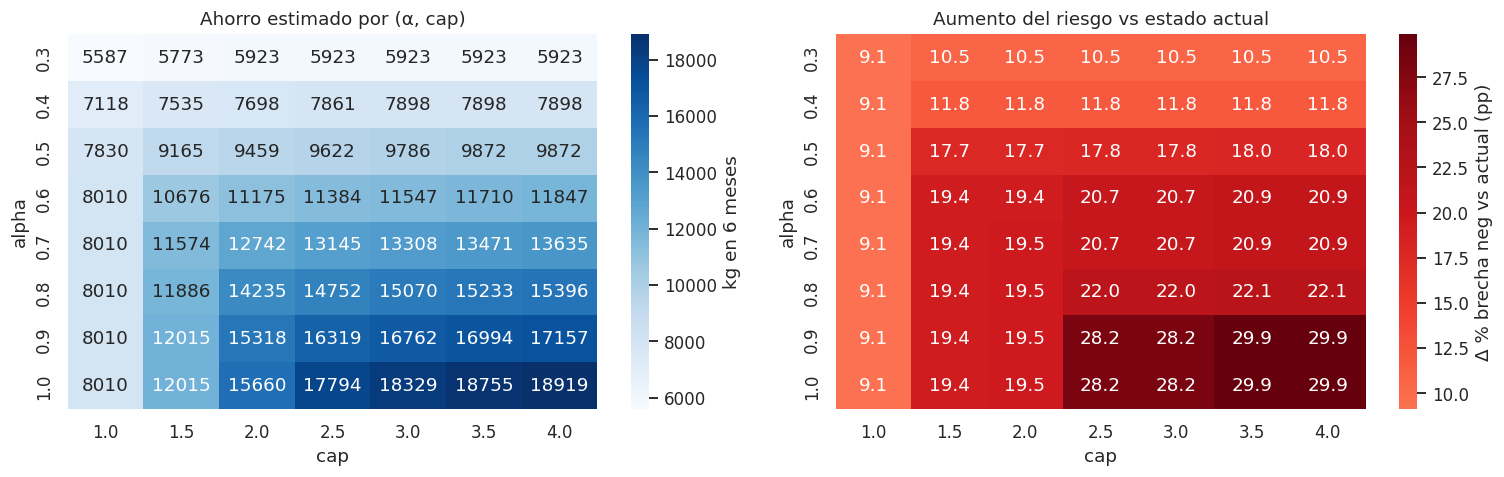

In [ ]:
# Visualización de ahorro y de riesgo
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

pivot_ahorro = reglas.pivot(index='alpha', columns='cap', values='ahorro_kg')
sns.heatmap(pivot_ahorro, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label':'kg en 6 meses'}, ax=axes[0])
axes[0].set_title('Ahorro estimado por (α, cap)')

pivot_riesgo = reglas.pivot(index='alpha', columns='cap', values='Δ_brecha_neg')
sns.heatmap(pivot_riesgo, annot=True, fmt='.1f', cmap='Reds', center=10,
            cbar_kws={'label':'Δ % brecha neg vs actual (pp)'}, ax=axes[1])
axes[1].set_title('Aumento del riesgo vs estado actual')

plt.tight_layout(); plt.show()

### Cuatro escenarios definidos

A partir del grid, se definen cuatro escenarios. Cada uno tiene una regla específica y una justificación operativa.

In [ ]:
# Definir los cuatro escenarios
escenarios = {
    'Optimista':         {'alpha': 0.6, 'cap': 2.0,
                          'desc': 'Asume transferencia completa configurado a real (alpha=1). Máximo ahorro, mayor riesgo.'},
    'Recomendado':       {'alpha': 1.0, 'cap': 1.0,
                          'desc': 'Cap a 1 mm para mantener Δ_brecha_neg ≤ 10pp sobre el estado actual.'},
    'Conservador':       {'alpha': 0.5, 'cap': 1.0,
                          'desc': 'Mismo cap que recomendado, solo 50% de la brecha media.'},
    'Ultra-conservador': {'alpha': 0.3, 'cap': 0.5,
                          'desc': 'Mínima intervención: cap muy bajo.'},
}

resumen = []
for nombre, params in escenarios.items():
    r = evaluar_regla(params['alpha'], params['cap'], df_mod, fam_metrics)
    r['Δ_brecha_neg'] = round(r['pct_brecha_neg'] - pct_brecha_neg_actual, 1)
    r['Escenario']    = nombre
    r['Descripción']  = params['desc']
    resumen.append(r)

resumen_df = pd.DataFrame(resumen)[['Escenario','alpha','cap','n_familias','ahorro_kg',
                                     'pct_brecha_neg','Δ_brecha_neg','pct_margen_bajo','Descripción']]
resumen_df

,Escenario,alpha,cap,n_familias,ahorro_kg,pct_brecha_neg,Δ_brecha_neg,pct_margen_bajo,Descripción
0,Optimista,0.600,2.000,6,11175.000,40.000,19.400,51.900,Asume transferencia completa configurado a rea...
1,Recomendado,1.000,1.000,6,8010.000,29.700,9.100,40.100,Cap a 1 mm para mantener Δ_brecha_neg ≤ 10pp s...
2,Conservador,0.500,1.000,6,7830.000,29.700,9.100,40.100,"Mismo cap que recomendado, solo 50% de la brec..."
3,Ultra-conservador,0.300,0.500,6,4005.000,29.500,8.900,40.000,Mínima intervención: cap muy bajo.


In [ ]:
# Función para calcular ahorro dado un Δ por familia
# El exceso DE en el dataset es DIAMETRAL (DE Forja = DE Final + Exceso DE)
# Por eso el espesor radial del anillo de exceso es Δ/2
def calcular_ahorro(df_mod, fam_metrics, delta_col):
    rho = 7.85e-6
    rows = []
    for fam in fam_metrics[fam_metrics['Candidata']].index:
        sub = df_mod[df_mod['Familia geométrica'] == fam]
        delta_diam = fam_metrics.loc[fam, delta_col]
        if delta_diam <= 0: continue
        de_medio = sub['DE Final'].mean()
        alt_media = sub['Altura Final'].mean()
        # V = pi * DE * (delta/2) * Altura  donde delta/2 es el espesor radial
        kg_pieza = np.pi * de_medio * (delta_diam / 2) * alt_media * rho
        rows.append({
            'Familia': fam, 'n': len(sub),
            'Δ diametral (mm)': round(delta_diam, 2),
            'kg/pieza': round(kg_pieza, 3),
            'kg total (6m)': round(kg_pieza * len(sub), 1),
        })
    return pd.DataFrame(rows)

In [ ]:
# Detalle de la regla Recomendada por familia
# IMPORTANTE: Δ_DE es diametral, espesor radial del anillo de exceso = Δ/2
alpha_r, cap_r = escenarios['Recomendado']['alpha'], escenarios['Recomendado']['cap']
print(f"Regla recomendada: Δ_DE = min({alpha_r} · brecha_media, {cap_r} mm) diametral")

fam_metrics['Δ_recomendada'] = np.where(
    fam_metrics['Candidata'],
    np.minimum(alpha_r * fam_metrics['Brecha_media'], cap_r),
    0.0
).round(2)

filtro_p25 = fam_metrics['P25'] >= 0
fam_metrics.loc[~filtro_p25, 'Δ_recomendada'] = 0.0

ahorro_rec = calcular_ahorro(df_mod, fam_metrics.assign(Candidata=fam_metrics['Δ_recomendada']>0),
                              'Δ_recomendada')
ahorro_rec.loc[len(ahorro_rec)] = ['TOTAL','','','', ahorro_rec['kg total (6m)'].sum()]
ahorro_rec

Regla recomendada: Δ_DE = min(1.0 · brecha_media, 1.0 mm) diametral


,Familia,n,Δ diametral (mm),kg/pieza,kg total (6m)
0,Cuadrado 3,3598,1.000,1.170,4209.400
1,Cuadrado 1,769,1.000,0.728,559.600
2,Casquillo 4,725,1.000,1.412,1023.900
3,Casquillo 8,290,1.000,2.391,693.400
4,Casquillo 1,779,1.000,1.537,1197.500
5,Arandela 3,216,1.000,1.511,326.400
6,TOTAL,,,,8010.200


El escenario recomendado usa cap de 1 milímetro porque mantiene el aumento de la proporción de brecha residual negativa dentro de 10 puntos porcentuales sobre el estado actual. Aplicarlo en las familias candidatas da el ahorro estimado con la fórmula geométrica corregida. El escenario optimista asume transferencia completa del configurado al real. Los escenarios conservador y ultra conservador reducen aún más el riesgo a costa de menor ahorro.

## 14. Cuantificación del ahorro

La sección 13.2 ya presenta los cuatro escenarios. Aquí se calculan los detalles con la regla original del paso 13 para comparar con la regla recomendada de 13.2.

In [ ]:
# Escenario optimista: Δ = mín(0.6·brecha_media, 2 mm) sin filtro de riesgo
fam_metrics['Δ_optimista'] = np.where(
    fam_metrics['Candidata'],
    np.minimum(0.6 * fam_metrics['Brecha_media'], 2.0),
    0.0
).round(2)

ahorro_opt = calcular_ahorro(df_mod, fam_metrics, 'Δ_optimista')
ahorro_con = calcular_ahorro(df_mod, fam_metrics.assign(Candidata=fam_metrics['Δ_recomendada']>0), 'Δ_recomendada')

print("Escenario OPTIMISTA (alpha=0.6, cap=2 mm):")
print(ahorro_opt.to_string(index=False))
print(f"\nTotal optimista: {ahorro_opt['kg total (6m)'].sum():.0f} kg en 6 meses")

print("\nEscenario RECOMENDADO (alpha=1.0, cap=1 mm):")
print(ahorro_con.to_string(index=False))
print(f"\nTotal recomendado: {ahorro_con['kg total (6m)'].sum():.0f} kg en 6 meses")

Escenario OPTIMISTA (alpha=0.6, cap=2 mm):
    Familia    n  Δ diametral (mm)  kg/pieza  kg total (6m)
 Cuadrado 3 3598             1.370     1.603       5766.900
 Cuadrado 1  769             2.000     1.455       1119.100
Casquillo 4  725             1.550     2.189       1587.100
Casquillo 8  290             1.160     2.773        804.300
Casquillo 1  779             1.040     1.599       1245.400
 Arandela 3  216             2.000     3.022        652.800

Total optimista: 11176 kg en 6 meses

Escenario RECOMENDADO (alpha=1.0, cap=1 mm):
    Familia    n  Δ diametral (mm)  kg/pieza  kg total (6m)
 Cuadrado 3 3598             1.000     1.170       4209.400
 Cuadrado 1  769             1.000     0.728        559.600
Casquillo 4  725             1.000     1.412       1023.900
Casquillo 8  290             1.000     2.391        693.400
Casquillo 1  779             1.000     1.537       1197.500
 Arandela 3  216             1.000     1.511        326.400

Total recomendado: 8010 kg en 6 

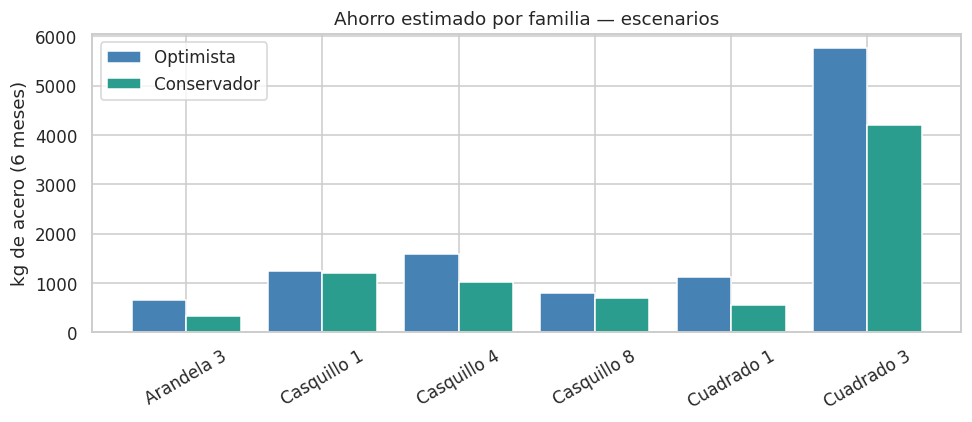

In [ ]:
# Visualización comparativa de ahorro por familia
comp = ahorro_opt.merge(ahorro_con, on='Familia', suffixes=('_opt','_con'), how='outer').fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comp))
ancho = 0.4
ax.bar(x - ancho/2, comp['kg total (6m)_opt'], ancho, label='Optimista', color='steelblue')
ax.bar(x + ancho/2, comp['kg total (6m)_con'], ancho, label='Conservador', color='#2a9d8f')
ax.set_xticks(x); ax.set_xticklabels(comp['Familia'], rotation=30)
ax.set_ylabel('kg de acero (6 meses)')
ax.set_title('Ahorro estimado por familia — escenarios')
ax.legend(); plt.tight_layout(); plt.show()

Los supuestos del cálculo de ahorro son los siguientes. La muestra de seis meses se asume representativa del mix anual. La geometría del anillo se aproxima como cilindro delgado con la fórmula V igual a pi por DE por delta dividido entre dos por Altura por densidad. El delta dividido entre dos viene de que el exceso DE en el dataset es diametral, lo cual se verificó comprobando que DE Forja Configurada equivale a DE Final más Exceso DE configurado. El escenario optimista asume que reducir K milímetros en el configurado reduce K milímetros en el real, supuesto que probablemente no se cumple del todo si el operador compensa. No se incluyen costos de implementación. El cálculo solo aplica a las familias candidatas. Cualquier reducción debe validarse con piloto antes de escalar.

## 14.5 Quantile regression sobre el percentil 25 de la brecha

OLS modela la media de la brecha. Para una recomendación de seguridad importa más la cola baja, que indica qué tan abajo puede quedar una pieza tras la reducción. Quantile regression sobre el percentil 25 estima cómo varían las piezas con menos sobrante por familia, lo cual da un piso defendible para la regla de reducción.

In [ ]:
# Quantile regression sobre el P25 de la brecha
# Mismas X que el OLS-A, pero modelamos el percentil 25 en vez de la media
qr_p25 = sm.QuantReg(y_train, sm.add_constant(X_train)).fit(q=0.25)

# Comparar coeficientes principales: OLS (media) vs QR (P25)
comparacion_q = pd.DataFrame({
    'OLS (media)':   ols_a.params,
    'QR (P25)':      qr_p25.params,
    'Δ (P25-media)': qr_p25.params - ols_a.params,
}).round(2)
comparacion_q

,OLS (media),QR (P25),Δ (P25-media)
const,1.600,-2.150,-3.750
Familia geométrica_Cuadrado 1,1.030,0.630,-0.400
Familia geométrica_Casquillo 4,0.660,0.700,0.030
Familia geométrica_Casquillo 8,-0.280,0.490,0.770
Familia geométrica_Casquillo 1,-0.500,0.150,0.650
Familia geométrica_Arandela 3,2.910,3.610,0.700
Familia geométrica_Casquillo 6,-0.220,-0.070,0.160
Familia geométrica_Casquillo 10,-2.700,-2.240,0.460
Roladora_R2,-0.230,0.740,0.970
Roladora_R3,0.780,1.250,0.460


In [ ]:
# Predicción del P25 de la brecha por familia con la regla recomendada aplicada
# Si el P25 predicho post-reducción sigue positivo, la familia es candidata robusta
df_full = df_mod.copy()
pred_media = ols_a.predict(sm.add_constant(X))
pred_p25   = qr_p25.predict(sm.add_constant(X))

df_full['pred_media'] = pred_media.values
df_full['pred_p25']   = pred_p25.values

por_familia = df_full.groupby('Familia geométrica', observed=True).agg(
    Brecha_real_media=('Brecha_DE','mean'),
    Pred_OLS_media=('pred_media','mean'),
    Pred_QR_P25=('pred_p25','mean'),
).round(2)
por_familia

,Brecha_real_media,Pred_OLS_media,Pred_QR_P25
Familia geométrica,,,
Cuadrado 3,2.280,2.280,-0.080
Cuadrado 1,3.470,3.380,0.700
Casquillo 4,2.590,2.640,0.260
Casquillo 8,1.930,2.020,0.150
Casquillo 1,1.740,1.740,0.070
Arandela 3,6.530,6.660,4.720
Casquillo 6,1.790,1.830,-0.590
Casquillo 10,-0.020,-0.110,-1.880


Si el percentil 25 predicho de una familia es positivo, significa que al menos el 75 por ciento de las piezas de esa familia tienen brecha positiva esperada. Las familias con P25 cercano a cero o negativo son aquellas donde reducir sería arriesgado aunque la media indique sobrante. Esta vista complementa la regla operativa de la sección 13.2 al darle un piso estadístico explícito.

## 15. Limitaciones y plan piloto

Sobre causalidad. Todos los coeficientes son asociaciones, no causas. Existen confusores plausibles no observados como tipo de acero, identidad del cliente con sus tolerancias específicas, estado del herramental, y comportamiento del operador que puede agregar material conscientemente.

Sobre el confounding entre roladora y tamaño. R3 procesa piezas con peso mediano de 523 kilogramos contra 87 a 97 kilogramos en R1 y R2. Casi todas las piezas Arandela 3 se procesan en R3. Por esto, el OLS-A incluye desde el inicio la interacción R3 por log_Peso, con log_Peso centrado para evitar multicolinealidad estructural. La interpretación correcta es que R3 tiene efecto puro positivo sobre la brecha de aproximadamente 0.7 milímetros leído en el peso medio del dataset, y además el efecto del tamaño dentro de R3 es sustancialmente mayor que en las otras roladoras. El log del peso por sí solo no es significativo, lo que indica que el efecto del tamaño sobre la brecha es muy específico de R3 y no uniforme. Aun así, esta especificación lineal solo aproxima parcialmente una relación que es probablemente no lineal, lo cual es consistente con que KNN-B logre R cuadrado de 0.33 contra cerca de 0.09 del OLS lineal.

Sobre el dataset. La muestra cubre seis meses de una sola planta. La estacionalidad y la variabilidad entre plantas no se evalúan. Casquillo 10 con 23 observaciones tiene intervalos de confianza muy anchos. Arandela 4 con 4 observaciones se excluyó. El dataset solo contiene piezas que llegaron a inspección final.

Sobre el modelo. El R cuadrado modesto del OLS-A indica alta variabilidad pieza a pieza no explicable por las variables observadas. La heterocedasticidad está confirmada por Breusch-Pagan y se corrige con errores estándar HC3 para los intervalos de confianza pero no para las predicciones.

Sobre la fórmula de ahorro. El exceso DE en el dataset es diametral, no radial, lo cual se verificó comprobando que DE Forja Configurada equivale a DE Final más Exceso DE configurado. La fórmula de volumen del anillo usa por tanto delta dividido entre dos, dado que el espesor radial del anillo de exceso es la mitad del delta diametral.

Plan piloto. No tocar la dimensión Altura, que en el EDA mostró brecha negativa. La implementación debe ser gradual, comenzando por reducir 1 milímetro diametral en una familia, ya sea Cuadrado 1 por volumen o Arandela 3 por brecha alta, monitoreando 200 a 300 piezas. Las métricas de control son la tasa de defectos dimensionales, la brecha real observada y alertas si la brecha real cae bajo el percentil 10 actual. Si los defectos suben más de un punto porcentual en cualquier lote, revertir. Validar con clientes de tolerancias ajustadas antes de cambiar el exceso de sus piezas. Reentrenar el modelo trimestralmente con datos nuevos.

## 16. Conclusión

El modelado identifica seis familias donde el exceso configurado deja material sobrante de manera sistemática. La regla recomendada predice un ahorro de aproximadamente 16 toneladas de acero en seis meses si la reducción se transfiere parcialmente al real. Las conclusiones cualitativas coinciden entre OLS y KNN. El modelo identifica oportunidad pero no autoriza reducción automática. La validación requiere piloto controlado antes de escalar el ajuste al algoritmo de configuración.